# 4. Валидация и интерпретация модели

Структура раздела:
- 4.1 Загрузка модели и данных
- 4.2 Confusion Matrix
- 4.3 ROC-кривая (сравнение моделей)
- 4.4 Precision-Recall кривая
- 4.5 SHAP — интерпретация предсказаний
- 4.6 Итоговые выводы

## 4.1 Загрузка модели и данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score,
                             precision_recall_curve, average_precision_score)
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

/Users/shoxrux/PycharmProjects/Churn Prediction/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Данные
X_test_raw  = pd.read_csv('../data/train_test/X_test_raw.csv')
X_test      = pd.read_csv('../data/train_test/X_test.csv')
X_train_raw = pd.read_csv('../data/train_test/X_train_raw.csv')
X_train     = pd.read_csv('../data/train_test/X_train.csv')
y_test      = pd.read_csv('../data/train_test/y_test.csv').squeeze()
y_train     = pd.read_csv('../data/train_test/y_train.csv').squeeze()

cb_tuned = joblib.load('../models/catboost_model.pkl')
scaler   = joblib.load('../models/scaler.pkl')

# Переобучаем LR для сравнения на ROC-кривой
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Вероятности
cb_probs = cb_tuned.predict_proba(X_test_raw)[:, 1]
lr_probs = lr.predict_proba(X_test)[:, 1]

print("Данные и модели загружены успешно")

Данные и модели загружены успешно


## 4.2 Confusion Matrix

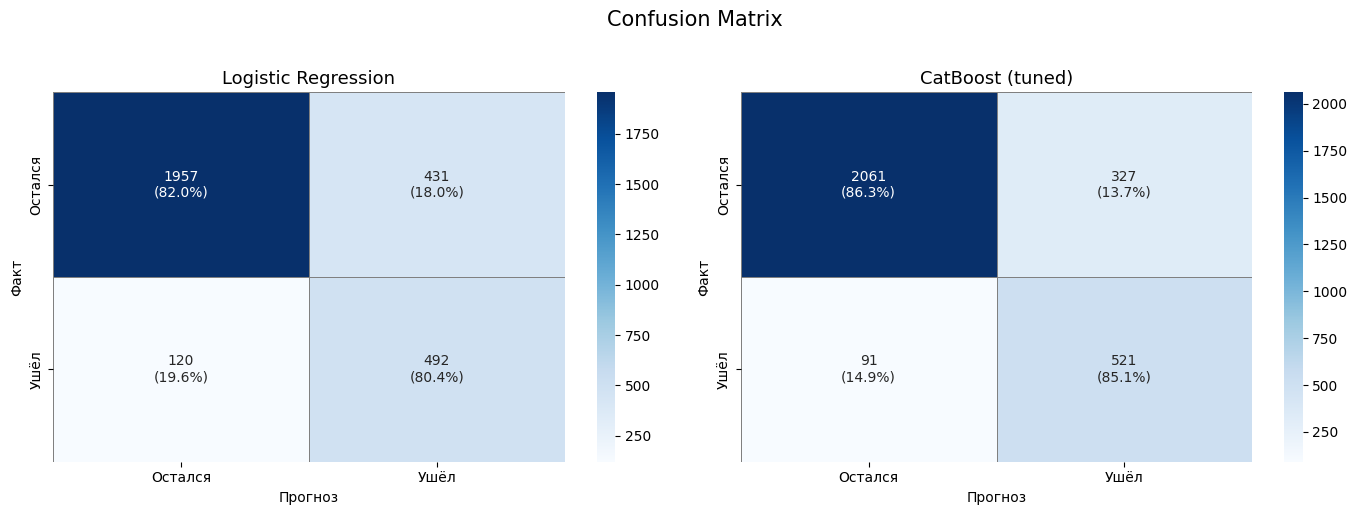

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, probs, name in zip(axes,
                            [lr_probs, cb_probs],
                            ['Logistic Regression', 'CatBoost (tuned)']):
    preds = (probs >= 0.5).astype(int)
    cm = confusion_matrix(y_test, preds)
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm, annot=np.array([[f'{v}\n({p:.1f}%)' for v, p in zip(row, prow)]
                                     for row, prow in zip(cm, cm_pct)]),
                fmt='', cmap='Blues', ax=ax,
                xticklabels=['Остался', 'Ушёл'],
                yticklabels=['Остался', 'Ушёл'],
                linewidths=0.5, linecolor='gray')
    ax.set_title(f'{name}', fontsize=13)
    ax.set_ylabel('Факт')
    ax.set_xlabel('Прогноз')

plt.suptitle('Confusion Matrix', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('graphs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.3 ROC-кривая и Precision-Recall кривая

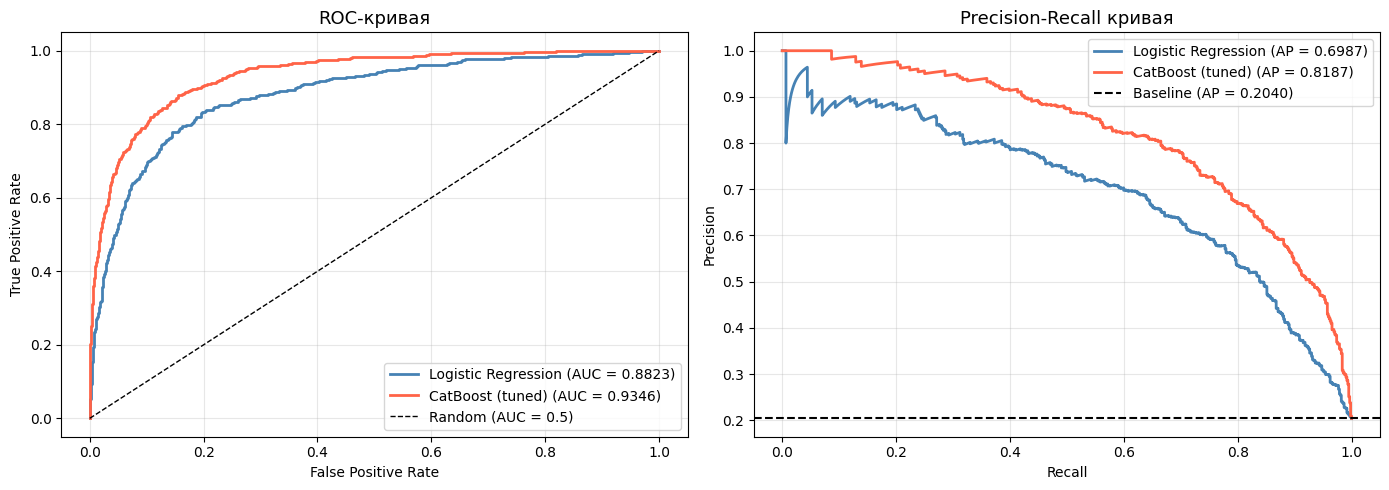

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC-кривая ------------------------------------------
for probs, name, color in zip([lr_probs, cb_probs],
                               ['Logistic Regression', 'CatBoost (tuned)'],
                               ['steelblue', 'tomato']):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
axes[0].set_title('ROC-кривая', fontsize=13)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precision-Recall кривая ------------------------------------------
for probs, name, color in zip([lr_probs, cb_probs],
                               ['Logistic Regression', 'CatBoost (tuned)'],
                               ['steelblue', 'tomato']):
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[1].plot(recall, precision, color=color, linewidth=2,
                 label=f'{name} (AP = {ap:.4f})')

axes[1].axhline(y_test.mean(), color='black', linestyle='--',
                label=f'Baseline (AP = {y_test.mean():.4f})')
axes[1].set_title('Precision-Recall кривая', fontsize=13)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('graphs/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.4 SHAP — интерпретация модели

SHAP (SHapley Additive exPlanations) объясняет вклад каждого признака
в конкретное предсказание модели. В отличие от feature importance,
SHAP показывает не только *какой* признак важен, но и *как* он влияет —
повышает или снижает вероятность оттока.

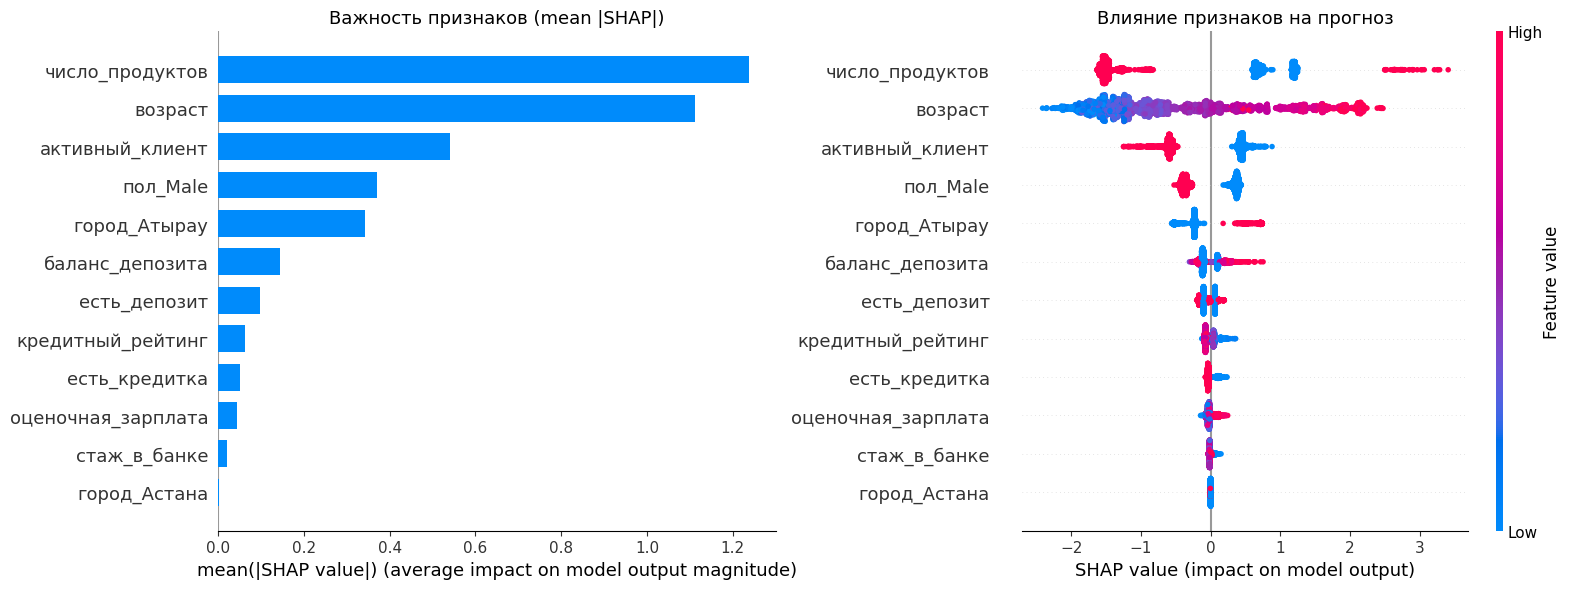

In [5]:
explainer = shap.TreeExplainer(cb_tuned)
shap_values = explainer.shap_values(X_test_raw)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1 — Bar plot (средняя важность признаков)
plt.sca(axes[0])
shap.summary_plot(shap_values, X_test_raw, plot_type='bar',
                  show=False, plot_size=None)
axes[0].set_title('Важность признаков (mean |SHAP|)', fontsize=13)

# График 2 — Beeswarm (направление влияния) (тоже самое что и SHAP, только и по -X)
plt.sca(axes[1])
shap.summary_plot(shap_values, X_test_raw, show=False, plot_size=None)
axes[1].set_title('Влияние признаков на прогноз', fontsize=13)

plt.tight_layout()
plt.savefig('graphs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.5 Интерпретация SHAP

**Топ признаков по важности:**

- `число_продуктов` — самый важный признак. Beeswarm чётко показывает:
  низкое значение (1 продукт, синий цвет) резко повышает вероятность оттока
  (SHAP уходит вправо до +3-4). Высокое значение (2+ продукта) — снижает риск.

- `возраст` — второй по важности. Высокий возраст (розовый) сдвигает прогноз
  вправо — повышает вероятность оттока. Подтверждает выводы EDA.

- `активный_клиент` — неактивные клиенты (низкое значение, синий)
  показывают отрицательный SHAP — то есть неактивность сильно повышает
  риск ухода.

- `пол_Male` — мужской пол (высокое значение) снижает вероятность оттока,
  что согласуется с EDA: женщины уходят вдвое чаще.

- `город_Атырау` — наличие этого признака (розовый) сдвигает прогноз вправо,
  подтверждая аномально высокий отток в Атырау (42%).

- `стаж_в_банке`, `город_Астана`, `оценочная_зарплата` — минимальный вклад,
  SHAP значения близки к нулю. Признаки малоинформативны для модели,
  что согласуется с корреляционным анализом из раздела 2.4.

**Ключевой портрет клиента группы риска:**
Пожилая женщина из Атырау, неактивный клиент с 1 продуктом и депозитом.

## 4.6 Калибровка модели

Калибровка показывает, насколько предсказанные вероятности
соответствуют реальным долям положительного класса.
Идеальная калибровка = кривая совпадает с диагональю.

Calibration set: 1500 samples
Evaluation set:  1500 samples
Positive rate:   0.204


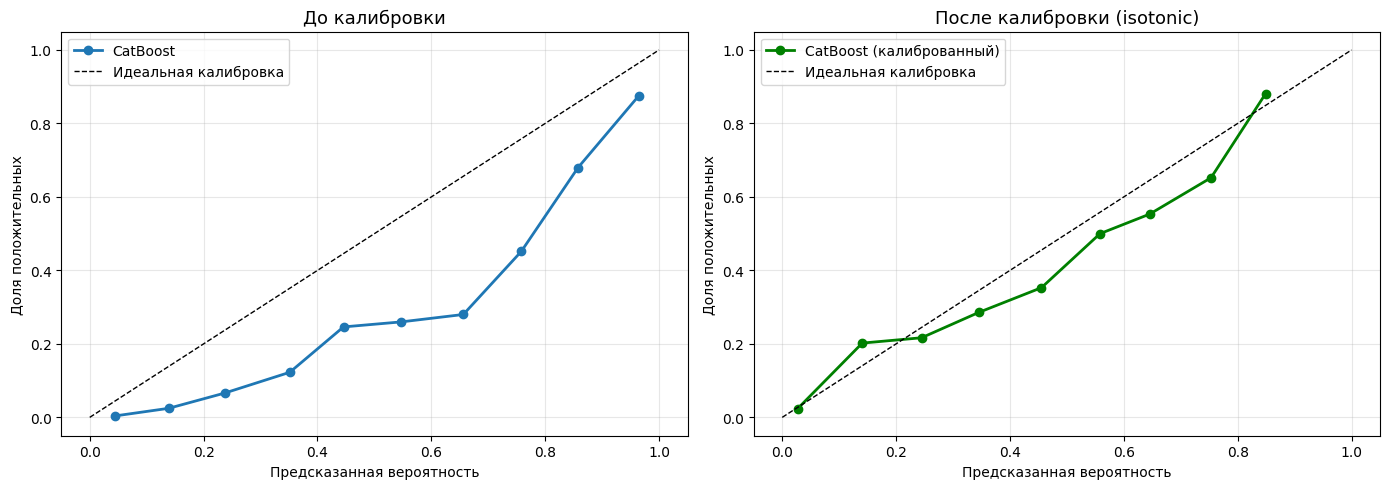

Brier Score до калибровки:    0.1009
Brier Score после калибровки: 0.0773


In [12]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss

# Делим test на calibration (50%) и evaluation (50%)
X_cal, X_eval, y_cal, y_eval, cb_probs_cal_raw, cb_probs_eval_raw = train_test_split(
    X_test_raw, y_test, cb_probs, test_size=0.5, random_state=42, stratify=y_test
)

# Калибровка — правильный способ для sklearn 1.6+
calibrated = CalibratedClassifierCV(FrozenEstimator(cb_tuned), method='sigmoid')
calibrated.fit(X_cal, y_cal)
cb_probs_cal = calibrated.predict_proba(X_eval)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- До калибровки ---
prob_true, prob_pred = calibration_curve(y_eval, cb_probs_eval_raw, n_bins=10)
axes[0].plot(prob_pred, prob_true, marker='o', linewidth=2, label='CatBoost')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Идеальная калибровка')
axes[0].set_title('До калибровки', fontsize=13)
axes[0].set_xlabel('Предсказанная вероятность')
axes[0].set_ylabel('Доля положительных')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- После калибровки ---
prob_true_cal, prob_pred_cal = calibration_curve(y_eval, cb_probs_cal, n_bins=10)
axes[1].plot(prob_pred_cal, prob_true_cal, marker='o', linewidth=2, color='green', label='CatBoost (калиброванный)')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Идеальная калибровка')
axes[1].set_title('После калибровки (isotonic)', fontsize=13)
axes[1].set_xlabel('Предсказанная вероятность')
axes[1].set_ylabel('Доля положительных')
axes[1].legend()
axes[1].grid(alpha=0.3)

print(f"Calibration set: {len(X_cal)} samples")
print(f"Evaluation set:  {len(X_eval)} samples")
print(f"Positive rate:   {y_cal.mean():.3f}")

plt.tight_layout()
plt.savefig('graphs/calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Brier Score до калибровки:    {brier_score_loss(y_eval, cb_probs_eval_raw):.4f}")
print(f"Brier Score после калибровки: {brier_score_loss(y_eval, cb_probs_cal):.4f}")

In [ ]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss
from scipy.optimize import minimize_scalar
from scipy.special import expit, logit
import matplotlib.pyplot as plt
import numpy as np

# ─────────────────────────────────────────────
# 1. Сплит
# ─────────────────────────────────────────────
X_cal, X_eval, y_cal, y_eval, cb_probs_cal_raw, cb_probs_eval_raw = train_test_split(
    X_test_raw, y_test, cb_probs, test_size=0.5, random_state=42, stratify=y_test
)

# ─────────────────────────────────────────────
# 2. Три метода калибровки
# ─────────────────────────────────────────────

# Sigmoid (Platt)
cal_sigmoid = CalibratedClassifierCV(FrozenEstimator(cb_tuned), method='sigmoid')
cal_sigmoid.fit(X_cal, y_cal)
cb_probs_sigmoid = cal_sigmoid.predict_proba(X_eval)[:, 1]

# Isotonic
cal_isotonic = CalibratedClassifierCV(FrozenEstimator(cb_tuned), method='isotonic')
cal_isotonic.fit(X_cal, y_cal)
cb_probs_isotonic = cal_isotonic.predict_proba(X_eval)[:, 1]

# Temperature scaling
def brier_with_temp(T):
    scaled = expit(logit(cb_probs_cal_raw.clip(1e-6, 1-1e-6)) / T)
    return brier_score_loss(y_cal, scaled)

T_opt = minimize_scalar(brier_with_temp, bounds=(0.1, 10.0), method='bounded').x
cb_probs_temp = expit(logit(cb_probs_eval_raw.clip(1e-6, 1-1e-6)) / T_opt)

# ─────────────────────────────────────────────
# 3. Brier Scores
# ─────────────────────────────────────────────
scores = {
    'До калибровки':      brier_score_loss(y_eval, cb_probs_eval_raw),
    'Sigmoid':            brier_score_loss(y_eval, cb_probs_sigmoid),
    'Isotonic':           brier_score_loss(y_eval, cb_probs_isotonic),
    f'Temperature (T={T_opt:.2f})': brier_score_loss(y_eval, cb_probs_temp),
}

for name, score in scores.items():
    print(f"Brier Score [{name}]: {score:.4f}")

# ─────────────────────────────────────────────
# 4. Графики — все 4 на одном figure
# ─────────────────────────────────────────────
methods_plot = {
    'До калибровки':               (cb_probs_eval_raw, '#2563EB'),
    'Sigmoid':                     (cb_probs_sigmoid,  '#9333EA'),
    'Isotonic':                    (cb_probs_isotonic, '#16A34A'),
    f'Temperature (T={T_opt:.2f})': (cb_probs_temp,    '#EA580C'),
}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.patch.set_facecolor('#F8FAFC')

for ax, (title, (probs, color)) in zip(axes, methods_plot.items()):
    pt, pp = calibration_curve(y_eval, probs, n_bins=10)
    brier = brier_score_loss(y_eval, probs)

    ax.set_facecolor('#F8FAFC')
    ax.fill_between(pp, pp, pt, alpha=0.1, color=color)
    ax.plot([0, 1], [0, 1], '--', linewidth=1.2, color='#94A3B8', label='Идеальная')
    ax.plot(pp, pt, marker='o', linewidth=2.2, color=color,
            markeredgecolor='white', markeredgewidth=1.2, label=title)

    ax.text(0.04, 0.93, f'Brier: {brier:.4f}',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#E5E7EB', alpha=0.9))

    ax.set_title(title, fontsize=12, fontweight='semibold', color='#111827')
    ax.set_xlabel('Предсказанная вероятность', fontsize=10)
    ax.set_ylabel('Доля положительных', fontsize=10)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(alpha=0.25, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('graphs/calibration_curve.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## 4.7 SHAP — Feature Importance

Горизонтальная столбчатая диаграмма средней абсолютной
SHAP-ценности для каждого признака.

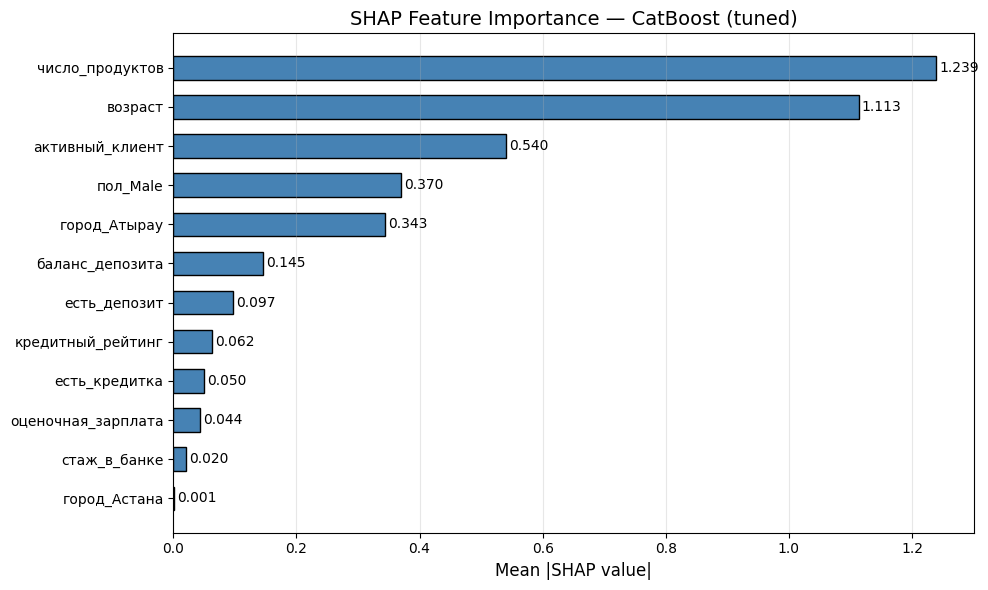

In [7]:
shap_importance = pd.DataFrame({
    'feature': X_test_raw.columns,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(shap_importance['feature'], shap_importance['importance'],
               color='steelblue', edgecolor='black', height=0.6)
ax.set_xlabel('Mean |SHAP value|', fontsize=12)
ax.set_title('SHAP Feature Importance — CatBoost (tuned)', fontsize=14)
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, shap_importance['importance']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('graphs/shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4.8 Итоговые выводы

### Качество модели
Финальная модель — CatBoost с подобранными гиперпараметрами —
демонстрирует высокое качество на тестовой выборке:

| Метрика    | Значение |
|------------|:--------:|
| ROC-AUC    | 0.9347   |
| F1         | 0.7169   |
| Precision  | 0.6175   |
| Recall     | 0.8546   |
| CV ROC-AUC | 0.9368 ± 0.0043 |

### Интерпретация результатов
Confusion Matrix показывает: из 612 реально ушедших клиентов
модель правильно идентифицирует 523 (85.5%) — это критически важно
для бизнеса, так как пропущенный отток дороже ложной тревоги.

### Портрет клиента группы риска
По совокупности EDA и SHAP-анализа наиболее склонен к уходу клиент:
- **Возраст:** 45+ лет
- **Пол:** женский
- **Город:** Атырау
- **Активность:** неактивный клиент
- **Продукты:** только 1 продукт в банке
- **Депозит:** имеется, но активность низкая

### Рекомендации для бизнеса
- Приоритетная группа для retention-кампаний — неактивные клиенты
  с 1 продуктом старше 45 лет
- Отдельное внимание региону Атырау — отток 42% требует
  локального расследования причин
- Подключение второго продукта значительно снижает риск оттока —
  кросс-продажи как инструмент удержания